In [4]:
# === 0) Imports & config ======================================================
import os, random
import h5py, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import get_worker_info
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

file_path   = "/home/katya.govorkova/gwak2/gwak/output/dataset_train_HL_SR4096_kernel1.0_5696_17procent.h5"
RANDOM_STATE= 42
BATCH_SIZE  = 64
EPOCHS      = 8
LR          = 1e-3
WD          = 1e-4
CKPT_PATH   = "best_cnn.pt"   # best model by val AUC

# Recommended for some filesystems to avoid lock hangs
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

# Repro
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.benchmark = True

# Speed hint (PyTorch >= 2.0)
try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

# === 1) Label map & helpers ===================================================
background_like = {"Background", "Glitch"}
signal_like     = {"BBH","CCSN","Cusp","Gaussian","Kink","KinkKink","SineGaussian","WhiteNoiseBurst"}
label_map = {**{k:0 for k in background_like}, **{k:1 for k in signal_like}}

with h5py.File(file_path, "r") as f:
    keys = list(f.keys())
    prefixes = sorted({k[:-5] for k in keys if k.endswith("_data")})
    print("Found data types:", prefixes)

    index = []   # list of (prefix, local_idx, label)
    n_per_class = {}
    for p in prefixes:
        if p not in label_map:  # skip unknown
            continue
        n = f[f"{p}_data"].shape[0]
        n_per_class[p] = n
        index.extend([(p, j, label_map[p]) for j in range(n)])
        print(f"{p:15s} N={n} label={label_map[p]}")

index = np.array(index, dtype=object)  # columns: [prefix, local_idx, label]
y_all = index[:, 2].astype(np.int64)
idx_all = np.arange(len(index))

# stratified split on labels
idx_trainval, idx_test = train_test_split(idx_all, test_size=0.15, stratify=y_all, random_state=RANDOM_STATE)
y_trainval = y_all[idx_trainval]
idx_train, idx_val = train_test_split(idx_trainval, test_size=0.17647, stratify=y_trainval, random_state=RANDOM_STATE)

print(f"Splits -> train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}")

# === 3) HDF5-backed Dataset (no z-norm) ======================================
class H5WaveDataset(Dataset):
    def __init__(self, file_path, index_array):
        self.file_path = file_path
        self.index = np.array(index_array)
        self.h5 = None
        self.rng = random.Random(RANDOM_STATE)
        self.read_errors = 0  # count OSErrors encountered

    def _ensure_open(self):
        if self.h5 is None:
            # one read-only handle per worker/process (no SWMR)
            self.h5 = h5py.File(self.file_path, "r")
            wi = get_worker_info()
            if wi is not None:
                self.rng.seed(RANDOM_STATE + wi.id + os.getpid())
                
    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        self._ensure_open()
        p, j, lbl = self.index[i]
        lbl = float(lbl)
        j = int(j)

        # robust read with a couple retries (skips corrupted chunks)
        tries = 0
        while True:
            try:
                x = self.h5[f"{p}_data"][j]
                return torch.from_numpy(x), torch.tensor(lbl, dtype=torch.float32)
            except OSError:
                tries += 1
                self.read_errors += 1
                if tries >= 3:
                    # fall back to a zero sample with correct shape
                    ds = self.h5[f"{p}_data"]
                    shape = (2, 4096)
                    x = np.zeros(shape, dtype=np.float32)
                    return torch.from_numpy(x), torch.tensor(lbl, dtype=torch.float32)
                # pick another sample from same class
                n = self.h5[f"{p}_data"].shape[0]
                j = self.rng.randrange(0, n)

    def __del__(self):
        try:
            if self.h5 is not None:
                self.h5.close()
        except Exception:
            pass

train_ds = H5WaveDataset(file_path, index[idx_train])
val_ds   = H5WaveDataset(file_path, index[idx_val])
test_ds  = H5WaveDataset(file_path, index[idx_test])

# --- DataLoaders (start safe: no multiprocessing; then bump to 1-2 if stable) -
NUM_WORKERS = 0
PIN_MEMORY  = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)

# === 4) Tiny 1D CNN ===========================================================
class TinyCNN(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.fe = nn.Sequential(
            nn.Conv1d(in_ch, 16, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(16), nn.ReLU(inplace=True),
            nn.Conv1d(16, 32, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True),
            nn.Conv1d(32, 64, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(64, 1)

    def forward(self, x):              # (B,C,T)
        z = self.fe(x).squeeze(-1)    # (B,64)
        return self.head(z).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = TinyCNN(in_ch=2).to(device)

# class imbalance weight
pos = (y_all[idx_train] == 1).sum()
neg = (y_all[idx_train] == 0).sum()
pos_weight = torch.tensor([neg / max(pos, 1)], device=device, dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

# === AMP (new API) with clean CPU fallback ===================================
if torch.cuda.is_available():
    from torch import amp
    def autocast_cm():
        return amp.autocast('cuda')
    scaler = amp.GradScaler('cuda')
else:
    from contextlib import contextmanager
    @contextmanager
    def autocast_cm():
        yield
    class _DummyScaler:
        def scale(self, x): return x
        def step(self, opt): opt.step()
        def update(self): pass
    scaler = _DummyScaler()

# === 5) Eval helper ===========================================================
def evaluate(loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device)
            with autocast_cm():
                logits = model(xb)
            probs  = torch.sigmoid(logits)
            ys.append(yb.cpu().numpy())
            ps.append(probs.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    y_pred = (y_prob >= 0.5).astype(np.float32)
    acc = accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")
    return acc, auc, y_true, y_pred, y_prob

# === 6) Train (AMP + best checkpoint) ========================================
best_auc, best_state = -np.inf, None
for ep in range(1, EPOCHS+1):
    model.train()
    running, nseen = 0.0, 0
    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        with autocast_cm():
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item() * xb.size(0)
        nseen   += xb.size(0)

    train_loss = running / max(nseen, 1)
    val_acc, val_auc, *_ = evaluate(val_loader)
    print(f"Epoch {ep:02d} | train_loss {train_loss:.4f} | val_acc {val_acc:.3f} | val_auc {val_auc:.3f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}
        torch.save(best_state, CKPT_PATH)

# Restore best
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# === 7) Final evaluation ======================================================
val_acc, val_auc, vy, vy_hat, vy_prob = evaluate(val_loader)
test_acc, test_auc, ty, ty_hat, tp    = evaluate(test_loader)

print("\nValidation:  acc={:.3f}, auc={:.3f}".format(val_acc, val_auc))
print("Test:        acc={:.3f}, auc={:.3f}".format(test_acc, test_auc))
print("\nTest confusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(confusion_matrix(ty, ty_hat))
print("\nClassification report (test):")
print(classification_report(ty, ty_hat, target_names=["background-like","signal"]))

# Basic read-error stats
print(f"\n[IO] train read_errors={getattr(train_ds, 'read_errors', 0)}, "
      f"val read_errors={getattr(val_ds, 'read_errors', 0)}, "
      f"test read_errors={getattr(test_ds, 'read_errors', 0)}")
print(f"[Model] Best checkpoint saved to: {os.path.abspath(CKPT_PATH)}")

Found data types: ['BBH', 'Background', 'CCSN', 'Cusp', 'Gaussian', 'Glitch', 'Kink', 'KinkKink', 'SineGaussian', 'WhiteNoiseBurst']
BBH             N=175656 label=1
Background      N=162144 label=0
CCSN            N=175656 label=1
Cusp            N=175656 label=1
Gaussian        N=175656 label=1
Glitch          N=162144 label=0
Kink            N=175656 label=1
KinkKink        N=175656 label=1
SineGaussian    N=175656 label=1
WhiteNoiseBurst N=175656 label=1
Splits -> train=1210675, val=259430, test=259431
Epoch 01 | train_loss 0.1790 | val_acc 0.682 | val_auc 0.850
Epoch 02 | train_loss 0.1589 | val_acc 0.701 | val_auc 0.856
Epoch 03 | train_loss 0.1568 | val_acc 0.704 | val_auc 0.861
Epoch 04 | train_loss 0.1558 | val_acc 0.714 | val_auc 0.863
Epoch 05 | train_loss 0.1554 | val_acc 0.723 | val_auc 0.859
Epoch 06 | train_loss 0.1550 | val_acc 0.701 | val_auc 0.863
Epoch 07 | train_loss 0.1548 | val_acc 0.721 | val_auc 0.866
Epoch 08 | train_loss 0.1545 | val_acc 0.739 | val_auc 0.864


Collected: (259431,) (259431,)   positives=210788, negatives=48643


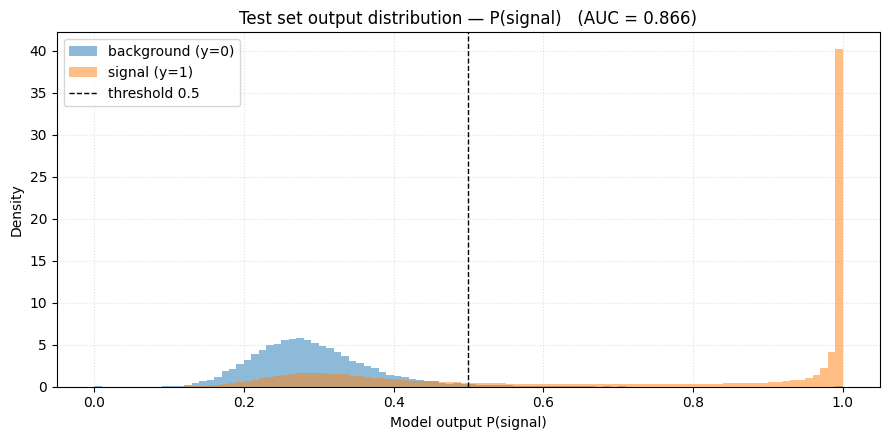

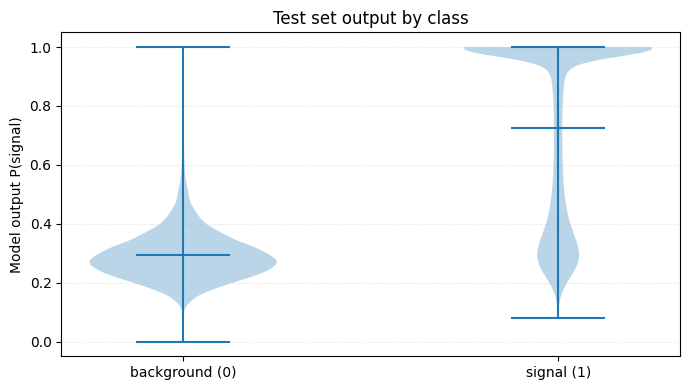

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ---- 1) Collect probabilities on the test set ----
# Uses existing model/device/test_loader; falls back if autocast_cm isn't defined.
from contextlib import nullcontext
_autocast = autocast_cm if 'autocast_cm' in globals() else nullcontext

model.eval()
y_true_list, y_prob_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        with _autocast():
            logits = model(xb)
            probs = torch.sigmoid(logits)
        y_true_list.append(yb.cpu().numpy())
        y_prob_list.append(probs.cpu().numpy())

y_true = np.concatenate(y_true_list).astype(int)
y_prob = np.concatenate(y_prob_list)

# Sanity prints
print("Collected:", y_true.shape, y_prob.shape, 
      f"  positives={int(y_true.sum())}, negatives={int((y_true==0).sum())}")

# ---- 2) Plot histogram of P(signal) for background vs signal ----
bins = np.linspace(0, 1, 101)
mask0 = (y_true == 0)   # background-like
mask1 = (y_true == 1)   # signal

plt.figure(figsize=(9, 4.5))
plt.hist(y_prob[mask0], bins=bins, density=True, alpha=0.5, label="background (y=0)")
plt.hist(y_prob[mask1], bins=bins, density=True, alpha=0.5, label="signal (y=1)")
plt.axvline(0.5, color="k", ls="--", lw=1, label="threshold 0.5")
if 'thr_f1' in globals():
    plt.axvline(float(thr_f1), color="r", ls=":", lw=1.5, label=f"best-F1 thr = {thr_f1:.3f}")
auc = roc_auc_score(y_true, y_prob)
plt.title(f"Test set output distribution — P(signal)   (AUC = {auc:.3f})")
plt.xlabel("Model output P(signal)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.show()

# ---- 3) (Optional) Violin/box plot for a different view ----
plt.figure(figsize=(7, 4))
data = [y_prob[mask0], y_prob[mask1]]
plt.violinplot(data, showmeans=True, showextrema=True)
plt.xticks([1, 2], ["background (0)", "signal (1)"])
plt.ylabel("Model output P(signal)")
plt.title("Test set output by class")
plt.grid(True, axis="y", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()